### Introduction to Neural Network Classification w/ Tensorflow

We're going to learn how to build neural network for classification problem.
Classification: Is where you try to classify something as one thing or another.

Types of classification problems:
- Binary Classification
- Multiclass Classification
- Multilabel Classification

#### Creating Data to View and Fit

In [91]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [92]:
# Check Feature
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [93]:
# Check Target
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [94]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0],"X1":X[:, 1], "y":y})
circles

,X0,X1,y
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


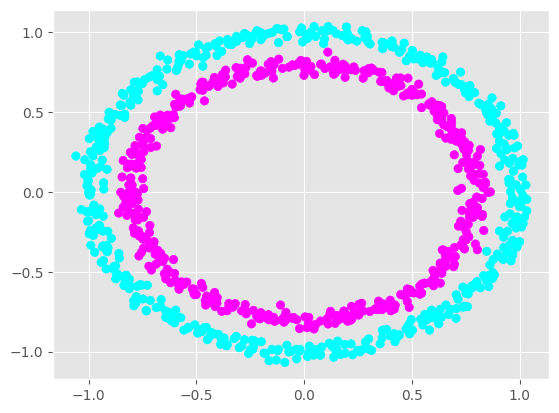

In [95]:
# Visualize DF
import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="cool")

#### Input & Output Shapes

In [96]:
# Shapes of the feature and target

X.shape, y.shape

((1000, 2), (1000,))

In [97]:
# Number of samples we're dealing with

len(X), len(y)

(1000, 1000)

In [98]:
# First data of each data
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

#### Data Splitting

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [100]:
# Train dataset shape
X_train.shape, y_train.shape

((700, 2), (700,))

In [101]:
# Test dataset shape
X_test.shape, y_test.shape

((300, 2), (300,))

#### Viusalize Train & Test Dataset

Text(0.5, 1.0, 'Visualize Train Dataset')

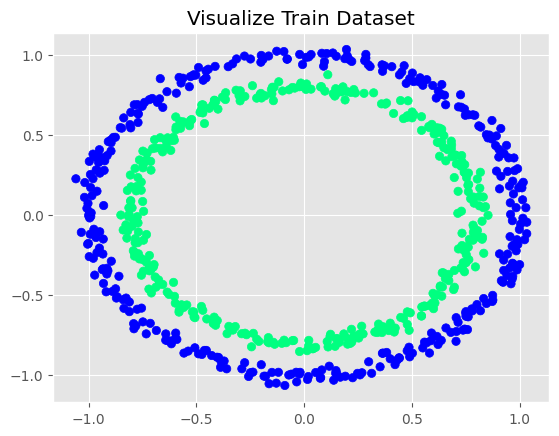

In [102]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="winter")
plt.title("Visualize Train Dataset")

Text(0.5, 1.0, 'Visualize Test Dataset')

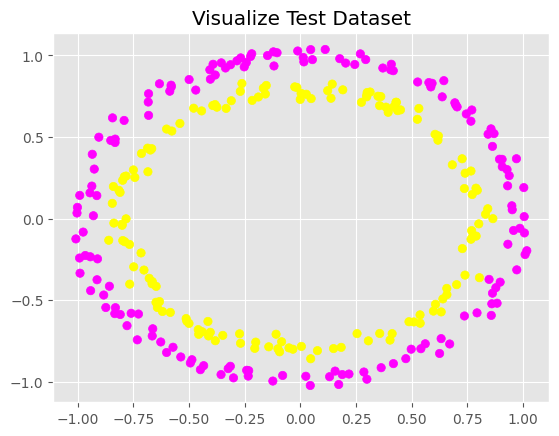

In [103]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="spring")
plt.title("Visualize Test Dataset")

#### Build a Model

In [104]:
import tensorflow as tf
from tensorflow import keras

In [105]:
tf.random.set_seed(42)

# Create Model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(3),
    tf.keras.layers.Dense(1)
])

# Compile model
model_1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss=tf.keras.losses.BinaryCrossentropy(),
                metrics=["accuracy"])

# Train model
model_1.fit(X_train, y_train, epochs=200, verbose=2)


Epoch 1/200
22/22 - 2s - 79ms/step - accuracy: 0.4743 - loss: 2.3809
Epoch 2/200
22/22 - 0s - 5ms/step - accuracy: 0.5129 - loss: 0.7051
Epoch 3/200
22/22 - 0s - 4ms/step - accuracy: 0.5143 - loss: 0.6995
Epoch 4/200
22/22 - 0s - 4ms/step - accuracy: 0.4929 - loss: 0.6946
Epoch 5/200
22/22 - 0s - 4ms/step - accuracy: 0.5043 - loss: 0.6945
Epoch 6/200
22/22 - 0s - 4ms/step - accuracy: 0.5157 - loss: 0.6948
Epoch 7/200
22/22 - 0s - 8ms/step - accuracy: 0.5143 - loss: 0.6950
Epoch 8/200
22/22 - 0s - 4ms/step - accuracy: 0.5057 - loss: 0.6951
Epoch 9/200
22/22 - 0s - 4ms/step - accuracy: 0.5071 - loss: 0.6953
Epoch 10/200
22/22 - 0s - 4ms/step - accuracy: 0.5000 - loss: 0.6954
Epoch 11/200
22/22 - 0s - 4ms/step - accuracy: 0.4986 - loss: 0.6955
Epoch 12/200
22/22 - 0s - 4ms/step - accuracy: 0.4971 - loss: 0.6956
Epoch 13/200
22/22 - 0s - 4ms/step - accuracy: 0.4971 - loss: 0.6957
Epoch 14/200
22/22 - 0s - 6ms/step - accuracy: 0.4929 - loss: 0.6957
Epoch 15/200
22/22 - 0s - 7ms/step - accur

#### Improve The Model

In [106]:
tf.random.set_seed(42)


# Build Model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation="relu"),
    tf.keras.layers.Dense(1)
])


# Compile Model 
model_2.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                loss = tf.keras.losses.BinaryCrossentropy(),
                metrics=["accuracy"])


# Training model
history2 = model_2.fit(X_train, y_train, epochs=250, verbose=2)


Epoch 1/250
22/22 - 1s - 51ms/step - accuracy: 0.3571 - loss: 0.9866
Epoch 2/250
22/22 - 0s - 6ms/step - accuracy: 0.2514 - loss: 0.8199
Epoch 3/250
22/22 - 0s - 4ms/step - accuracy: 0.1443 - loss: 0.7926
Epoch 4/250
22/22 - 0s - 4ms/step - accuracy: 0.2171 - loss: 0.7714
Epoch 5/250
22/22 - 0s - 5ms/step - accuracy: 0.2257 - loss: 0.7535
Epoch 6/250
22/22 - 0s - 4ms/step - accuracy: 0.1943 - loss: 0.7447
Epoch 7/250
22/22 - 0s - 4ms/step - accuracy: 0.1871 - loss: 0.7381
Epoch 8/250
22/22 - 0s - 4ms/step - accuracy: 0.1929 - loss: 0.7322
Epoch 9/250
22/22 - 0s - 4ms/step - accuracy: 0.2071 - loss: 0.7267
Epoch 10/250
22/22 - 0s - 4ms/step - accuracy: 0.2271 - loss: 0.7215
Epoch 11/250
22/22 - 0s - 6ms/step - accuracy: 0.2529 - loss: 0.7166
Epoch 12/250
22/22 - 0s - 6ms/step - accuracy: 0.2829 - loss: 0.7120
Epoch 13/250
22/22 - 0s - 6ms/step - accuracy: 0.3171 - loss: 0.7077
Epoch 14/250
22/22 - 0s - 6ms/step - accuracy: 0.3671 - loss: 0.7035
Epoch 15/250
22/22 - 0s - 7ms/step - accur

Text(0.5, 0, 'epochs')

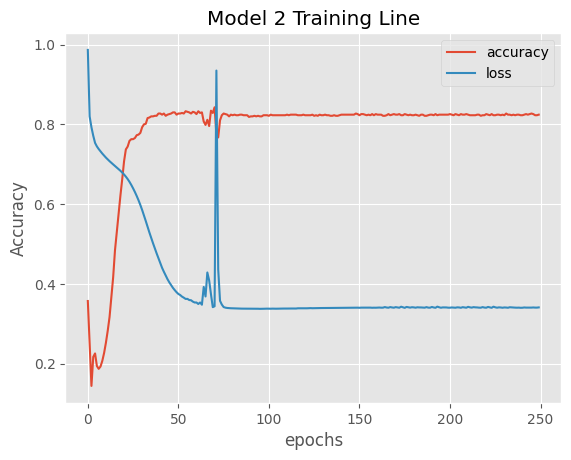

In [107]:
# Model 2 Training Visualize
pd.DataFrame(history2.history).plot()
plt.title("Model 2 Training Line")
plt.ylabel("Accuracy ")
plt.xlabel("epochs")

In [108]:
tf.random.set_seed(42)

# Build Model 3
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1)
])


# Compile Model 3
model_3.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                loss = tf.keras.losses.BinaryCrossentropy(),
                metrics=["accuracy"])


# Training Model 3

history3 = model_3.fit(X_train, y_train, epochs=100, verbose=2)

Epoch 1/100
22/22 - 1s - 62ms/step - accuracy: 0.4900 - loss: 1.7751
Epoch 2/100
22/22 - 0s - 10ms/step - accuracy: 0.4800 - loss: 0.8323
Epoch 3/100
22/22 - 0s - 8ms/step - accuracy: 0.4400 - loss: 0.7639
Epoch 4/100
22/22 - 0s - 4ms/step - accuracy: 0.4829 - loss: 0.7315
Epoch 5/100
22/22 - 0s - 4ms/step - accuracy: 0.5314 - loss: 0.7106
Epoch 6/100
22/22 - 0s - 5ms/step - accuracy: 0.5271 - loss: 0.6931
Epoch 7/100
22/22 - 0s - 6ms/step - accuracy: 0.5486 - loss: 0.6793
Epoch 8/100
22/22 - 0s - 4ms/step - accuracy: 0.5543 - loss: 0.6745
Epoch 9/100
22/22 - 0s - 3ms/step - accuracy: 0.5657 - loss: 0.6691
Epoch 10/100
22/22 - 0s - 4ms/step - accuracy: 0.5671 - loss: 0.6663
Epoch 11/100
22/22 - 0s - 4ms/step - accuracy: 0.5743 - loss: 0.6647
Epoch 12/100
22/22 - 0s - 4ms/step - accuracy: 0.5714 - loss: 0.6626
Epoch 13/100
22/22 - 0s - 4ms/step - accuracy: 0.5700 - loss: 0.6602
Epoch 14/100
22/22 - 0s - 4ms/step - accuracy: 0.5757 - loss: 0.6572
Epoch 15/100
22/22 - 0s - 8ms/step - accu

Text(0.5, 0, 'epochs')

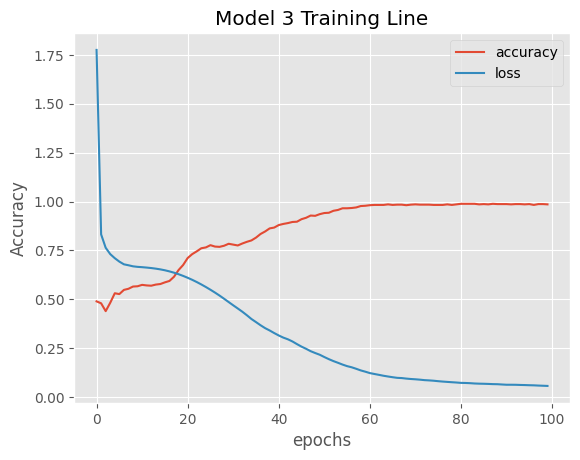

In [109]:
# Model 3 Training Visualize
pd.DataFrame(history3.history).plot()
plt.title("Model 3 Training Line")
plt.ylabel("Accuracy")
plt.xlabel("epochs")